# What does this portfolio actually own?

A walkthrough of the risk engine on a 20-name US small/mid-cap long-only book.

Set `LIVE = True` to pull real prices and Fama-French factors (needs internet, ~1 minute first run). The checked-in version of this notebook was run on the synthetic market so it renders on GitHub without any downloads; the analysis is identical either way.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from riskengine import *
from riskengine.tail import portfolio_returns, monte_carlo_var_cvar

plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.3})
INK, LOSS, MUTED = '#1B2A41', '#C0392B', '#8A94A6'

LIVE = False
AUM = 1_100_000

if LIVE:
    w, sectors = load_portfolio('../examples/portfolio.csv', with_sectors=True)
    md = load_market(list(w.index), start='2018-01-01', sectors=sectors)
else:
    md = synthetic_market(n_assets=20, n_days=2000, seed=11)
    w = pd.Series(np.random.default_rng(1).dirichlet(np.ones(20) * 3), index=md.tickers)

print(f'{len(w)} holdings, {len(md.returns)} trading days, {md.returns.index[0].date()} to {md.returns.index[-1].date()}')
w.sort_values(ascending=False).head(8).round(3)

20 holdings, 2000 trading days, 2019-01-08 to 2026-09-07


SMID16    0.128
SMID11    0.091
SMID02    0.075
SMID17    0.066
SMID04    0.056
SMID00    0.055
SMID01    0.055
SMID13    0.051
dtype: float64

## 1. Factor decomposition

Each stock's excess return is regressed on Fama-French 5 + momentum. Then the portfolio variance is split into what comes from factor exposures and what is stock-specific.

Annualised vol: 23.5%
  systematic:   22.0%  (88% of variance)
  idiosyncratic:8.2%  (12% of variance)


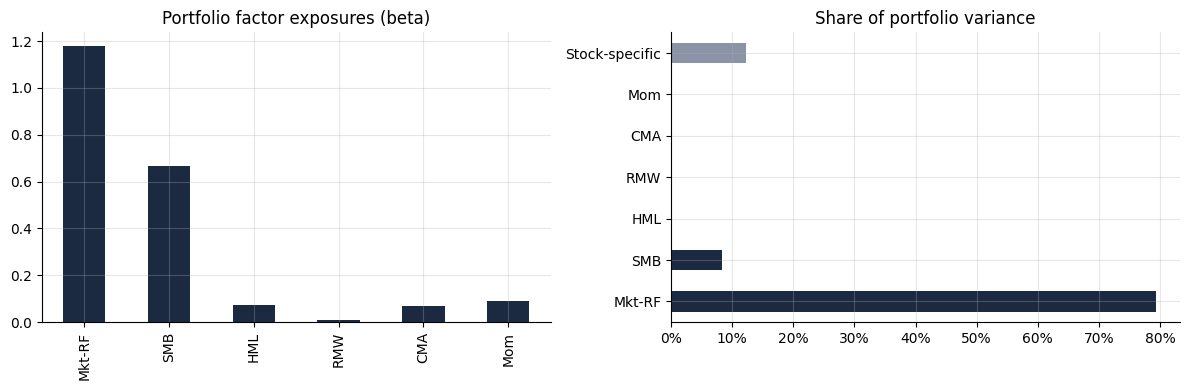

In [2]:
fm = fit_factor_model(md)
dec = fm.variance_decomposition(w)

print(f"Annualised vol: {dec['total_vol_annual']:.1%}")
print(f"  systematic:   {dec['factor_vol_annual']:.1%}  ({dec['factor_share']:.0%} of variance)")
print(f"  idiosyncratic:{dec['idio_vol_annual']:.1%}  ({dec['idio_share']:.0%} of variance)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
dec['exposures'].plot.bar(ax=ax[0], color=INK, title='Portfolio factor exposures (beta)')
ax[0].axhline(0, color='k', lw=0.5)
shares = dec['per_factor_share'].copy(); shares['Stock-specific'] = dec['idio_share']
shares.plot.barh(ax=ax[1], color=[INK]*6 + [MUTED], title='Share of portfolio variance')
ax[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()

The book is a levered bet on the market with a large small-cap tilt; everything else is noise by comparison. That's typical for a small/mid-cap fund, and it means diversification across names buys less than people expect: the names all share the same two drivers.

### Which names carry the specific risk?

Top 3 names = 6.2% of total variance via specific risk


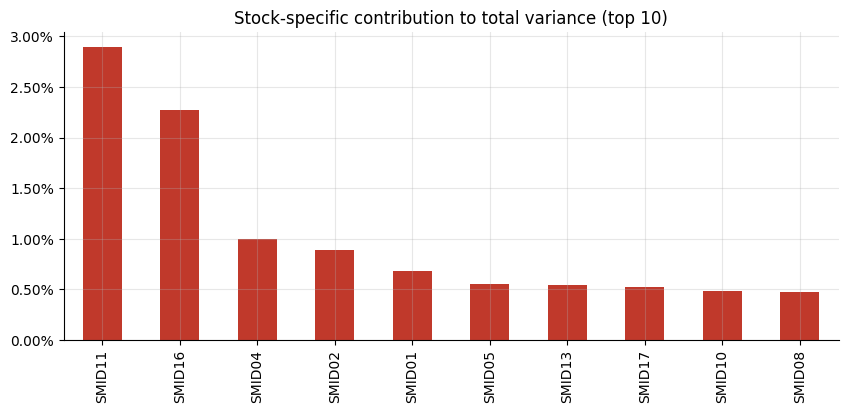

In [3]:
idio = fm.idio_contribution_by_stock(w)
ax = idio.head(10).plot.bar(color=LOSS, title='Stock-specific contribution to total variance (top 10)')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
print(f'Top 3 names = {idio.head(3).sum():.1%} of total variance via specific risk')

### Does the model need a sector factor?

The factor model assumes residuals are uncorrelated across stocks. If names in the same sector move together for reasons the FF factors don't capture, that assumption fails and idiosyncratic risk is understated. Test it: add market-orthogonalised sector factors and see whether residual correlation drops.

In [4]:
fm_sec = fit_factor_model(md, sectors=md.sectors)
r0, r1 = fm.residual_correlation_check(), fm_sec.residual_correlation_check()
print(f'Mean |residual correlation|:  FF only = {r0:.3f}   FF + sector = {r1:.3f}   ({(r1/r0-1):+.0%})')

sec_cols = [c for c in fm_sec.factor_names if c.startswith('SEC:')]
fm_sec.betas[sec_cols].round(2).head(10)

Mean |residual correlation|:  FF only = 0.059   FF + sector = 0.036   (-39%)


,SEC:Consumer,SEC:Healthcare,SEC:Industrials,SEC:Technology
SMID00,0.02,0.46,0.02,-0.01
SMID01,0.03,0.89,-0.00,0.01
SMID02,0.02,-0.05,-0.02,0.25
SMID03,0.47,-0.00,0.00,0.01
SMID04,-0.07,0.61,-0.02,0.04
SMID05,-0.06,0.71,-0.02,-0.04
SMID06,0.03,0.38,-0.02,0.02
SMID07,0.03,0.63,-0.02,-0.06
SMID08,-0.06,0.43,-0.01,0.02
SMID09,-0.03,0.01,0.62,0.00


### Are exposures stable?

A single-window beta is a snapshot. Roll it.

Market beta range: 1.10 to 1.25


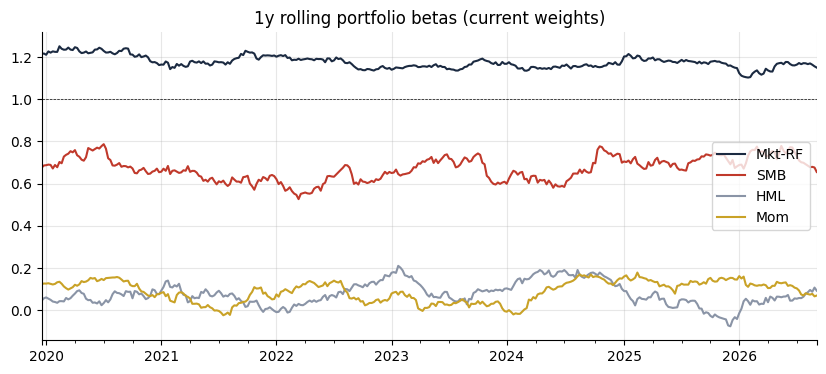

In [5]:
rb = rolling_betas(md, w, window=250, step=5)
ax = rb[['Mkt-RF', 'SMB', 'HML', 'Mom']].plot(color=[INK, LOSS, MUTED, '#C9A227'], lw=1.5,
                                              title='1y rolling portfolio betas (current weights)')
ax.axhline(1, color='k', lw=0.5, ls='--')
print(f"Market beta range: {rb['Mkt-RF'].min():.2f} to {rb['Mkt-RF'].max():.2f}")

## 2. Tail risk

VaR and CVaR at 99%, estimated four ways. The interesting number is the gap between the Gaussian and Student-t Monte Carlo: that's how much you'd understate tail loss by assuming normal returns.

In [6]:
R = md.returns.iloc[-500:]
t = tail_report(R, w, q=0.99)
print(f'Fitted Student-t degrees of freedom: {t.nu:.1f}')
t.table().style.format('{:.2%}')

Fitted Student-t degrees of freedom: 16.8


,VaR 99%,CVaR 99%
Historical,3.43%,4.25%
Parametric (Normal),3.56%,4.09%
Monte Carlo (Normal),3.60%,4.11%
Monte Carlo (Student-t),3.71%,4.40%


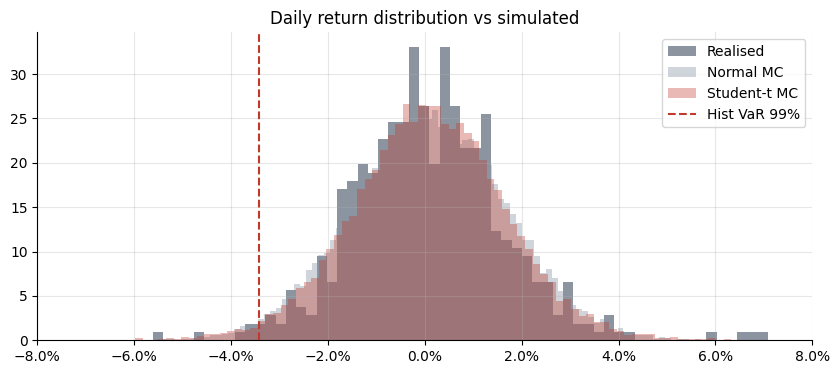

In [7]:
pr = portfolio_returns(R, w)
_, _, sim_t = monte_carlo_var_cvar(R, w, 0.99, n_sims=30000, dist='t')
_, _, sim_n = monte_carlo_var_cvar(R, w, 0.99, n_sims=30000, dist='normal')

fig, ax = plt.subplots()
ax.hist(pr, bins=60, density=True, alpha=0.5, color=INK, label='Realised')
ax.hist(sim_n, bins=100, density=True, alpha=0.4, color=MUTED, label='Normal MC')
ax.hist(sim_t, bins=100, density=True, alpha=0.35, color=LOSS, label='Student-t MC')
ax.axvline(-t.historical[0], color=LOSS, ls='--', label='Hist VaR 99%')
ax.set_xlim(-0.08, 0.08); ax.legend(); ax.set_title('Daily return distribution vs simulated')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

## 3. Does the VaR model actually work?

A VaR model is a forecast, so it can be backtested. Each day, estimate 99% VaR from the previous 250 days and check whether the next day's loss exceeded it. At 99% you expect a breach about 1% of the time.

Two tests: **Kupiec** asks whether the breach *count* is right. **Christoffersen** asks whether breaches are *independent* or come in clusters (a model that doesn't react to volatility regimes will fail this even if it passes Kupiec).

historical    25 breaches / 1750 days (expected 17.5)
             Kupiec:        PASS: breach rate consistent with 1% (p=0.090)
             Christoffersen: PASS: no evidence of breach clustering (p=0.394)



parametric    26 breaches / 1750 days (expected 17.5)
             Kupiec:        PASS: breach rate consistent with 1% (p=0.057)
             Christoffersen: PASS: no evidence of breach clustering (p=0.401)



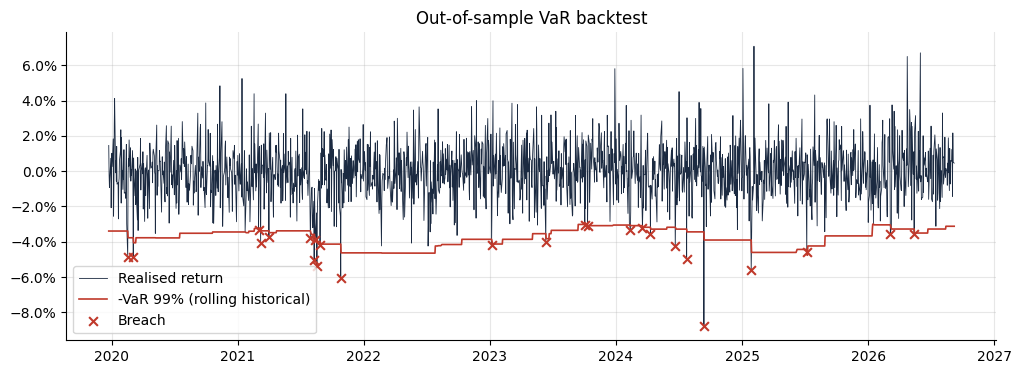

In [8]:
for method in ['historical', 'parametric']:
    bt = backtest_var(md.returns, w, q=0.99, window=250, method=method)
    print(f'{method:12s} {bt.n_breaches:3d} breaches / {bt.n_obs} days (expected {bt.expected_breaches:.1f})')
    print(f'{"":12s} Kupiec:        {bt.verdict}')
    print(f'{"":12s} Christoffersen: {bt.independence_verdict}\n')

bt = backtest_var(md.returns, w, q=0.99, window=250, method='historical')
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bt.realised, color=INK, lw=0.6, label='Realised return')
ax.plot(-bt.var_series, color=LOSS, lw=1.2, label='-VaR 99% (rolling historical)')
br = bt.realised[bt.breaches]
ax.scatter(br.index, br, color=LOSS, marker='x', s=40, zorder=3, label='Breach')
ax.legend(loc='lower left'); ax.set_title('Out-of-sample VaR backtest')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

## 4. Stress tests

Historical replay pushes realised factor returns from named crisis windows through the *current* exposures. Hypothetical shocks specify factor moves directly. Both report the factor-implied P&L with an idiosyncratic ±1σ band so the stock-specific noise is visible.

(On synthetic data the historical windows don't line up with real crashes; with `LIVE = True` they do.)

,Type,Days,Portfolio P&L,via Mkt-RF,via SMB,via HML,via RMW,via CMA,via Mom
Scenario,,,,,,,,,
COVID crash (Feb-Mar 2020),historical,24,-7.8%,-9.2%,+1.3%,-0.1%,+0.1%,+0.2%,+0.0%
2022 rate shock (Jan-Jun),historical,129,-9.3%,-15.5%,+5.8%,-0.1%,+0.0%,-0.1%,+0.5%
Aug 2024 carry unwind,historical,5,+2.7%,+3.0%,-0.2%,-0.1%,+0.0%,-0.0%,-0.0%
Broad selloff -10%,hypothetical,20,-11.8%,-11.8%,+0.0%,+0.0%,+0.0%,+0.0%,+0.0%
Small-cap rout,hypothetical,20,-16.1%,-9.4%,-6.7%,+0.0%,+0.0%,+0.0%,+0.0%
Value rotation,hypothetical,20,+0.0%,+0.0%,+0.0%,+0.7%,+0.0%,+0.0%,-0.7%
Quality flight,hypothetical,20,-9.2%,-5.9%,-3.3%,+0.0%,+0.0%,+0.0%,+0.0%
Momentum crash,hypothetical,20,+1.7%,+3.5%,+0.0%,+0.0%,+0.0%,+0.0%,-1.8%
Rally +10%,hypothetical,20,+14.4%,+11.8%,+2.7%,+0.0%,+0.0%,+0.0%,+0.0%


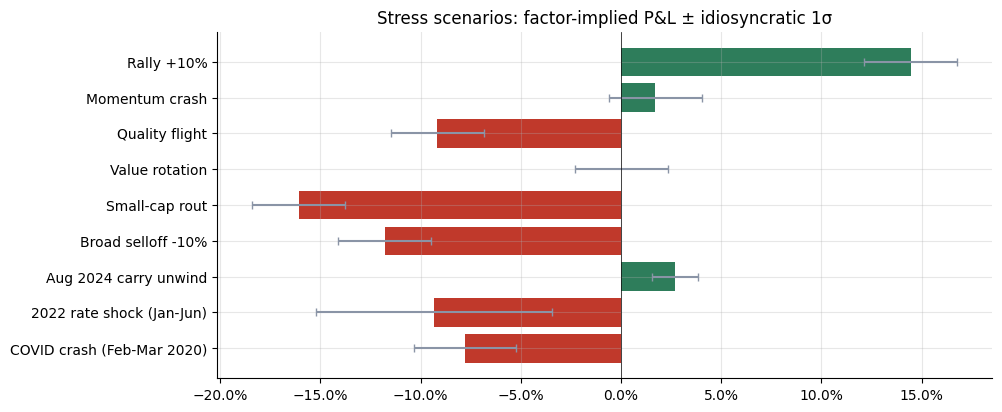

In [9]:
s = run_all_scenarios(fm, w, md.factors)
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [LOSS if v < 0 else '#2E7D5B' for v in s['Portfolio P&L']]
ax.barh(s.index, s['Portfolio P&L'], xerr=s['Idio ±1σ'], color=colors, ecolor=MUTED, capsize=3)
ax.axvline(0, color='k', lw=0.5); ax.set_title('Stress scenarios: factor-implied P&L ± idiosyncratic 1σ')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
s[['Type', 'Days', 'Portfolio P&L'] + [c for c in s.columns if c.startswith('via ')]].style.format(
    {c: '{:+.1%}' for c in s.columns if 'P&L' in c or c.startswith('via ')})

## 5. Portfolio construction

With 20 names and 500 days, the sample covariance has 210 free parameters estimated from noisy data. Ledoit-Wolf shrinkage pulls it toward a structured target. On top of that: how does the current book compare to equal-weight, minimum-variance, risk-parity and max-diversification allocations on the same names, all long-only with a 10% cap?

Ledoit-Wolf shrinkage intensity: 0.03
Effective number of bets: 16.2 of 20


,Ann. vol (shrunk cov),Ann. vol (realised),Eff. # of bets,Max weight,Top-5 weight
Current,24.6%,24.9%,16.2,12.8%,41.7%
Equal weight,25.1%,25.4%,19.7,5.0%,25.0%
Min variance,23.7%,23.9%,13.9,10.0%,47.5%
Risk parity,24.7%,25.0%,20.0,7.0%,29.3%
Max diversification,24.6%,24.9%,12.2,10.0%,50.0%


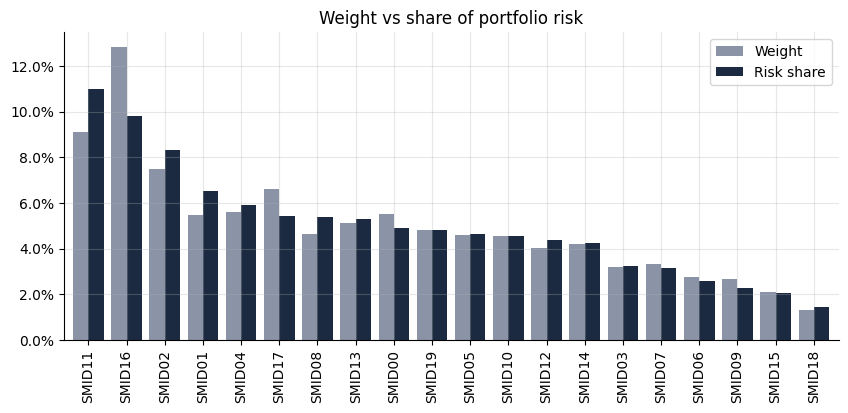

In [10]:
cov, delta = ledoit_wolf(R)
print(f'Ledoit-Wolf shrinkage intensity: {delta:.2f}')
rc = risk_contributions(w, cov).sort_values(ascending=False)
print(f'Effective number of bets: {effective_number_of_bets(w, cov):.1f} of {len(w)}')

fig, ax = plt.subplots()
pd.DataFrame({'Weight': w.reindex(rc.index), 'Risk share': rc}).plot.bar(ax=ax, color=[MUTED, INK], width=0.8,
    title='Weight vs share of portfolio risk')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

aw, ast = compare_allocations(R, w, max_weight=0.10)
ast.style.format({'Ann. vol (shrunk cov)': '{:.1%}', 'Ann. vol (realised)': '{:.1%}',
                  'Eff. # of bets': '{:.1f}', 'Max weight': '{:.1%}', 'Top-5 weight': '{:.1%}'})

## 6. Liquidity

A 1-day VaR on mid prices assumes you can exit in a day. For small caps, that depends on how big you are relative to average daily volume. This scales market risk by the square root of the liquidation horizon and adds a square-root-law impact cost, and reports the AUM at which the least liquid name becomes a 5-day exit.

In [11]:
vols = md.returns.iloc[-250:].std()
for aum in [1_100_000, 10_000_000, 50_000_000]:
    L = liquidity_adjusted_var(w, md.adv, aum, t.historical[0], participation=0.20, daily_vols=vols)
    p = L.attrs['portfolio']
    print(f"${aum/1e6:5.1f}M AUM: weighted exit {p['avg_liquidation_days']:4.1f}d, "
          f"L-VaR {p['liquidity_adjusted_var']:.2%} vs {p['base_var']:.2%} base, "
          f"slowest {L.index[0]} at {L['Days to liquidate'].iloc[0]:.1f}d")
print(f"\nCapacity: {p['capacity_binding_name']} needs >5 days at ${p['capacity_aum']/1e6:.1f}M AUM")
L.head(8).style.format({'Weight': '{:.1%}', 'Position $': '${:,.0f}', 'ADV $': '${:,.0f}',
                        'Days to liquidate': '{:.1f}', 'Impact cost (% of position)': '{:.2%}',
                        'Impact cost $': '${:,.0f}', 'Capacity AUM (5-day exit)': '${:,.0f}'})

$  1.1M AUM: weighted exit  1.0d, L-VaR 3.54% vs 3.43% base, slowest SMID02 at 1.5d
$ 10.0M AUM: weighted exit  2.6d, L-VaR 5.71% vs 3.43% base, slowest SMID02 at 13.9d
$ 50.0M AUM: weighted exit 11.5d, L-VaR 11.94% vs 3.43% base, slowest SMID02 at 69.3d

Capacity: SMID02 needs >5 days at $3.6M AUM


,Weight,Position $,ADV $,Days to liquidate,Impact cost (% of position),Impact cost $,Capacity AUM (5-day exit)
SMID02,7.5%,"$3,754,251","$270,796",69.3,1.01%,"$37,896","$3,606,528"
SMID04,5.6%,"$2,799,642","$621,728",22.5,0.61%,"$17,013","$11,103,711"
SMID13,5.1%,"$2,565,648","$657,263",19.5,0.50%,"$12,890","$12,808,902"
SMID10,4.5%,"$2,268,539","$637,631",17.8,0.48%,"$10,979","$14,053,788"
SMID00,5.5%,"$2,769,453","$895,723",15.5,0.37%,"$10,286","$16,171,479"
SMID05,4.6%,"$2,296,782","$1,309,946",8.8,0.37%,"$8,542","$28,516,979"
SMID12,4.0%,"$2,024,197","$1,284,451",7.9,0.28%,"$5,574","$31,727,421"
SMID16,12.8%,"$6,422,039","$4,824,311",6.7,0.22%,"$14,107","$37,560,582"


## 7. Everything at once

`run_full_analysis` runs all of the above and writes the findings in plain English. This is what the CLI prints and the dashboard shows at the top.

In [12]:
rep = run_full_analysis(md, w, q=0.99, portfolio_value=AUM)
for i, k in enumerate(rep.key_findings(), 1):
    print(f'{i:2d}. {k}\n')

 1. Annualised volatility is 23.5%: 88% systematic (factor) risk, 12% stock-specific.

 2. The largest single risk driver is Mkt-RF (79% of total variance). Portfolio beta to the market is 1.18, SMB exposure +0.67.

 3. SMID11 alone contributes 2.9% of total variance through stock-specific risk; the top 3 names account for 6.2%.

 4. 1-day 99% CVaR is 4.40% under a fat-tailed (Student-t, ν=16.8) model vs 4.09% assuming normality. Normal assumption understates tail loss by 8%.

 5. Rolling historical VaR backtest: 25 breaches in 1750 days (expected 17.5). Kupiec: PASS: breach rate consistent with 1% (p=0.090). Christoffersen: PASS: no evidence of breach clustering (p=0.394).

 6. Worst stress scenario is 'Small-cap rout' at -16.1% factor-implied P&L.

 7. Effective number of independent bets: 16.2 (out of 20 holdings). A risk-parity allocation on the same names would run at 24.7% vol vs 24.6% currently.

 8. Adding sector factors cut mean |residual correlation| from 0.059 to 0.036: the 

## What I'd do next

- Trade-list generator: the minimum-turnover path from current weights to a target allocation, subject to the participation cap.
- Regime-conditional VaR (e.g. GARCH-filtered historical simulation) to address breach clustering when the Christoffersen test fails.
- Replace yfinance sector labels with GICS sub-industries for a finer sector factor.